In [73]:
from selenium import webdriver
from bs4 import BeautifulSoup
import pandas as pd

driver = webdriver.Chrome()

url = "https://www.ambitionbox.com/reviews"

driver.get(url)

html = driver.page_source

soup = BeautifulSoup(html,"html.parser")

companies=[]

for company in soup.find_all("h2"):
    companies.append(company.text)

df = pd.DataFrame(companies,columns=["Company"])

df.to_csv("raw_data.csv",index=False)

driver.quit()

In [74]:
import pandas as pd

df = pd.read_csv("C:/Users/gayat/Downloads/ambitionbox_final_cleaned.csv")

print(df.head())

  Company Name  Rating   Reviews   Salaries  Interviews     Jobs  Benefits  \
0          TCS     3.3  120000.0  1020000.0     11800.0   4100.0   10800.0   
1    Accenture     3.7   74000.0   700000.0      9400.0  32500.0    6800.0   
2        Wipro     3.6   65500.0   490000.0      6900.0    302.0    4800.0   
3    Cognizant     3.7   61900.0   610000.0      6500.0    599.0    5600.0   
4    Capgemini     3.6   53800.0   500000.0      5600.0   2200.0    3700.0   

                       Type   Location                             Pros  \
0  IT Services & Consulting  Bengaluru                     Job Security   
1  IT Services & Consulting  Bengaluru                          Unknown   
2  IT Services & Consulting  Hyderabad                          Unknown   
3  IT Services & Consulting  Hyderabad                          Unknown   
4  IT Services & Consulting  Bengaluru  Work Life Balance, Job Security   

                                    Cons  
0  Promotions, Salary, Work Satisfact

In [75]:
df.shape

(9156, 11)

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9156 entries, 0 to 9155
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Company Name  9156 non-null   object 
 1   Rating        9156 non-null   float64
 2   Reviews       9156 non-null   float64
 3   Salaries      9156 non-null   float64
 4   Interviews    9156 non-null   float64
 5   Jobs          9156 non-null   float64
 6   Benefits      9156 non-null   float64
 7   Type          9156 non-null   object 
 8   Location      9156 non-null   object 
 9   Pros          9156 non-null   object 
 10  Cons          9156 non-null   object 
dtypes: float64(6), object(5)
memory usage: 787.0+ KB


In [77]:
df.isnull().sum()

Company Name    0
Rating          0
Reviews         0
Salaries        0
Interviews      0
Jobs            0
Benefits        0
Type            0
Location        0
Pros            0
Cons            0
dtype: int64

In [78]:
df.drop_duplicates(inplace=True)

In [79]:
numeric_cols = [
'Rating',
'Reviews',
'Salaries',
'Interviews',
'Jobs',
'Benefits'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col],errors='coerce')

In [80]:
df.fillna(0,inplace=True)

In [81]:
def rating_category(x):
    if x >= 4:
        return "Excellent"
    elif x >= 3:
        return "Good"
    else:
        return "Poor"

df["Rating_Category"] = df["Rating"].apply(rating_category)

In [82]:
df.head()

,Company Name,Rating,Reviews,Salaries,Interviews,Jobs,Benefits,Type,Location,Pros,Cons,Rating_Category
0,TCS,3.3,120000.0,1020000.0,11800.0,4100.0,10800.0,IT Services & Consulting,Bengaluru,Job Security,"Promotions, Salary, Work Satisfaction",Good
1,Accenture,3.7,74000.0,700000.0,9400.0,32500.0,6800.0,IT Services & Consulting,Bengaluru,Unknown,"Promotions, Salary, Work Satisfaction",Good
2,Wipro,3.6,65500.0,490000.0,6900.0,302.0,4800.0,IT Services & Consulting,Hyderabad,Unknown,"Promotions, Salary, Work Satisfaction",Good
3,Cognizant,3.7,61900.0,610000.0,6500.0,599.0,5600.0,IT Services & Consulting,Hyderabad,Unknown,"Promotions, Salary, Work Satisfaction",Good
4,Capgemini,3.6,53800.0,500000.0,5600.0,2200.0,3700.0,IT Services & Consulting,Bengaluru,"Work Life Balance, Job Security","Promotions, Salary, Work Satisfaction",Good


In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

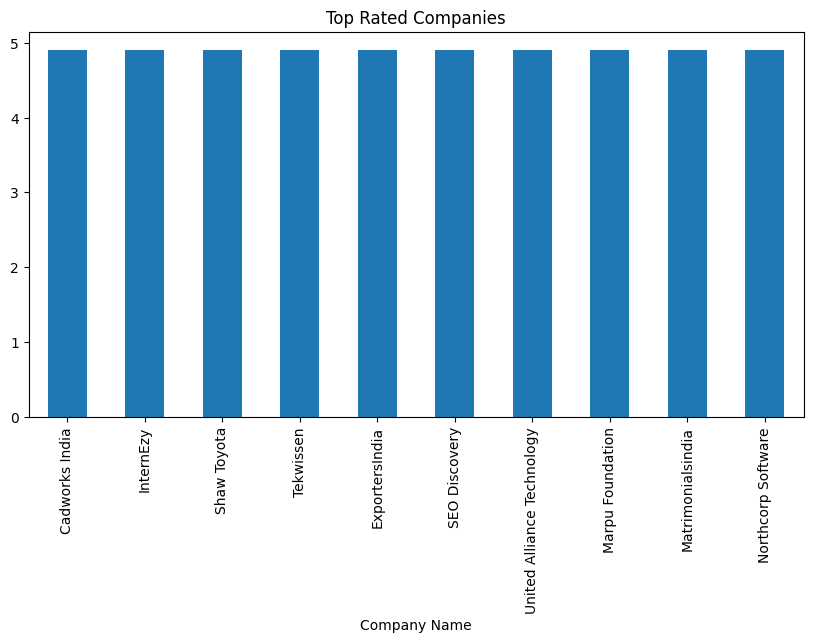

In [84]:
top_companies = (
    df.groupby("Company Name")["Rating"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
top_companies.plot(kind='bar')
plt.title("Top Rated Companies")
plt.show()

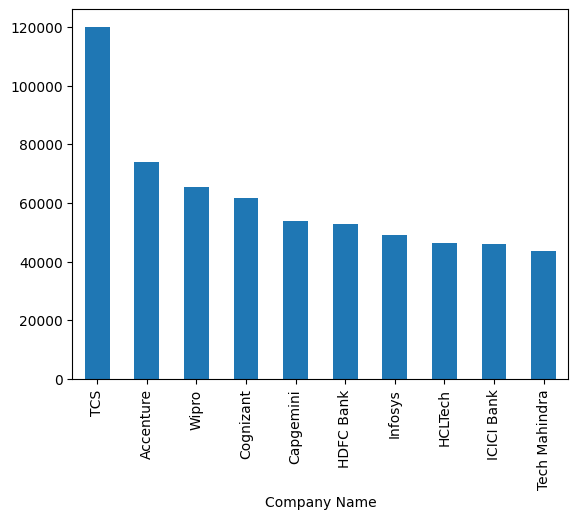

In [85]:
top_reviews = (
    df.groupby("Company Name")["Reviews"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_reviews.plot(kind='bar')
plt.show()

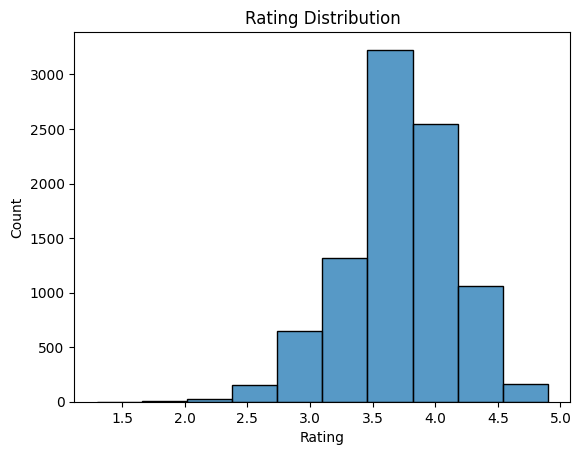

In [86]:
sns.histplot(df["Rating"],bins=10)

plt.title("Rating Distribution")

plt.show()

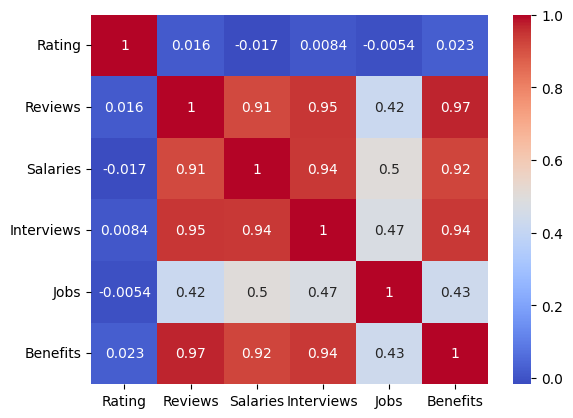

In [87]:
corr = df[
['Rating',
'Reviews',
'Salaries',
'Interviews',
'Jobs',
'Benefits']
].corr()

sns.heatmap(corr,annot=True,cmap="coolwarm")

plt.show()

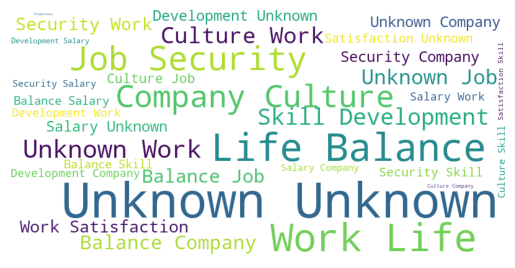

In [88]:
from wordcloud import WordCloud

text = " ".join(df['Pros'].astype(str))

wordcloud = WordCloud(
width=800,
height=400,
background_color='white'
).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

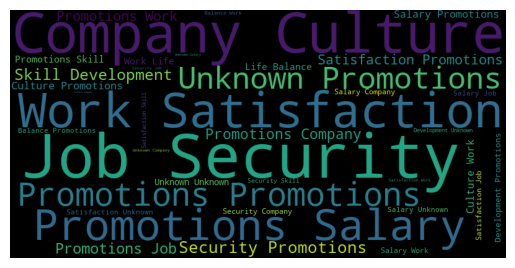

In [89]:
text = " ".join(df['Cons'].astype(str))

wordcloud = WordCloud(
width=800,
height=400
).generate(text)

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

In [90]:
from textblob import TextBlob

def sentiment(text):

    score = TextBlob(str(text)).sentiment.polarity

    if score > 0:
        return "Positive"

    elif score < 0:
        return "Negative"

    else:
        return "Neutral"

df["Pros_Sentiment"] = df["Pros"].apply(sentiment)

df["Cons_Sentiment"] = df["Cons"].apply(sentiment)

In [91]:
df["Pros_Sentiment"].value_counts()

Pros_Sentiment
Negative    5863
Neutral     3293
Name: count, dtype: int64

In [92]:
df.to_csv(
"final_dashboard_data.csv",
index=False
)

In [93]:
import pandas as pd

df = pd.read_csv("final_dashboard_data.csv")

In [102]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="G@yathri0813",
    database="ambitionbox"
)

cursor = conn.cursor()

In [103]:
print(df.columns.tolist())

['Company Name', 'Rating', 'Reviews', 'Salaries', 'Interviews', 'Jobs', 'Benefits', 'Type', 'Location', 'Pros', 'Cons', 'Rating_Category', 'Pros_Sentiment', 'Cons_Sentiment']


In [104]:
df.head()

,Company Name,Rating,Reviews,Salaries,Interviews,Jobs,Benefits,Type,Location,Pros,Cons,Rating_Category,Pros_Sentiment,Cons_Sentiment
0,TCS,3.3,120000.0,1020000.0,11800.0,4100.0,10800.0,IT Services & Consulting,Bengaluru,Job Security,"Promotions, Salary, Work Satisfaction",Good,Neutral,Neutral
1,Accenture,3.7,74000.0,700000.0,9400.0,32500.0,6800.0,IT Services & Consulting,Bengaluru,Unknown,"Promotions, Salary, Work Satisfaction",Good,Negative,Neutral
2,Wipro,3.6,65500.0,490000.0,6900.0,302.0,4800.0,IT Services & Consulting,Hyderabad,Unknown,"Promotions, Salary, Work Satisfaction",Good,Negative,Neutral
3,Cognizant,3.7,61900.0,610000.0,6500.0,599.0,5600.0,IT Services & Consulting,Hyderabad,Unknown,"Promotions, Salary, Work Satisfaction",Good,Negative,Neutral
4,Capgemini,3.6,53800.0,500000.0,5600.0,2200.0,3700.0,IT Services & Consulting,Bengaluru,"Work Life Balance, Job Security","Promotions, Salary, Work Satisfaction",Good,Neutral,Neutral


In [106]:
sql = """
INSERT INTO company_reviews
(company_name, rating, reviews, salaries,
 interviews, jobs, benefits, rating_category,
 Pros_Sentiment, Cons_Sentiment)
VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)
"""

data = []

for _, row in df.iterrows():
    data.append((
        row['Company Name'],
        row['Rating'],
        row['Reviews'],
        row['Salaries'],
        row['Interviews'],
        row['Jobs'],
        row['Benefits'],
        row['Rating_Category'],
        row['Pros_Sentiment'],
        row['Cons_Sentiment']
    ))

cursor.executemany(sql, data)
conn.commit()

In [107]:
print(conn)

In [ ]:
corr = df[
['Rating',
'Reviews',
'Salaries',
'Interviews',
'Jobs',
'Benefits']
].corr()

sns.heatmap(
corr,
annot=True,
cmap="coolwarm"
)

plt.show()